In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("cleaned_transactions.csv")

Build Risk Scoring Engine

In [4]:
df["risk_score"] = (
      df["customer_risk_score"] * 20
    + df["large_transaction"] * 20
    + df["foreign_currency"] * 15
    + df["cross_region"] * 10
    + df["invalid_bank"] * 15
    + df["night_transaction"] * 10
    + (df["transaction_count"] >= 10).astype(int) * 10
)

In [5]:
# Create Risk Levels
conditions = [
    df["risk_score"] >= 70,
    df["risk_score"] >= 40
]

choices = [
    "High",
    "Medium"
]

df["risk_level"] = np.select(
    conditions,
    choices,
    default="Low"
)

In [6]:
# Check Results
df[[
    "customer_id",
    "risk_score",
    "risk_level"
]].head()

,customer_id,risk_score,risk_level
0,734,45,Medium
1,962,75,High
2,143,75,High
3,760,55,Medium
4,175,55,Medium


In [9]:
print(df["risk_level"].value_counts())

risk_level
High      534
Medium    466
Name: count, dtype: int64


Distribution

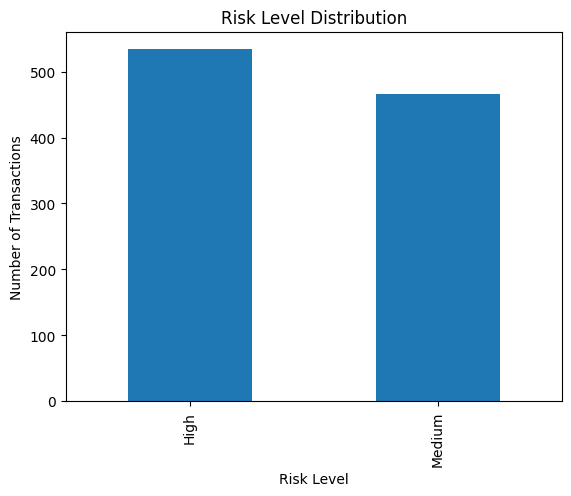

In [8]:
import matplotlib.pyplot as plt

df["risk_level"].value_counts().plot(kind="bar")

plt.title("Risk Level Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Transactions")

plt.show()

Model Evaluation

In [10]:
from sklearn.metrics import classification_report

y_true = df["is_high_risk"]

y_pred = (df["risk_level"] == "High").astype(int)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.50      0.51       493
           1       0.54      0.57      0.55       507

    accuracy                           0.53      1000
   macro avg       0.53      0.53      0.53      1000
weighted avg       0.53      0.53      0.53      1000



In [11]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[246 247]
 [220 287]]


In [12]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", round(accuracy, 2))

Accuracy: 0.53


In [13]:
# Precision, Recall and F1
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision :", precision_score(y_true, y_pred))
print("Recall    :", recall_score(y_true, y_pred))
print("F1 Score  :", f1_score(y_true, y_pred))

Precision : 0.5374531835205992
Recall    : 0.5660749506903353
F1 Score  : 0.5513928914505284
